# Señales y Sistemas (86.05/66.74/TB065) - TPE
# Primera Parte: Dominio de Tiempo

En esta primera parte del trabajo práctico se pide graficar dos señales de
audio en formato WAV en el dominio de tiempo; luego, para una de ellas
identificar diferentes notas musicales y calcular sus frecuencias fundamentales; finalmente,
para la señal de audio restante, identificar las diferencias entre instrumentos de
percusión e instrumentos armónicos.

Para la realización de los gráficos se utiliza el lenguaje de programación
[python](https://www.python.org) junto con las librerias
[scipy](https://docs.scipy.org/doc/scipy/index.html),
[matplotlib](https://matplotlib.org/) y
[numpy](https://numpy.org/doc/stable/index.html).

## Obtención y Muestra de Archivos

Empezamos importando las librerías mencionadas previamente en un nuevo script
de python.

In [8]:
import urllib.request
import matplotlib.pyplot as plt
import numpy as np

from scipy.io import wavfile

In [9]:
file1_name = 'InASentimentalMood.wav'
file2_name = 'Zombie.wav'

urllib.request.urlretrieve("https://github.com/mjkloeckner/TB065/raw/main/primera_parte/InASentimentalMood.wav", file1_name)
urllib.request.urlretrieve("https://github.com/mjkloeckner/TB065/raw/main/primera_parte/Zombie.wav", file2_name)

('Zombie.wav', <http.client.HTTPMessage at 0x7efa910ceb90>)

De la librería [scipy](https://docs.scipy.org/doc/scipy/index.html)
solo se importa la función
[wavfile](https://docs.scipy.org/doc/scipy/reference/io.html#module-scipy.io.wavfile),
ya que de esa librería solo utilizamos la misma.

Continuamos leyendo el contenido del primer archivo de nombre `InASentimentalMood.wav`,
para lo cual se utiliza la función `wavfile.read()` de la librería [scipy](https://docs.scipy.org/doc/scipy/index.html).
Esta función devuelve los datos y la tasa de muestreo del archivo en formato WAV
cuyo nombre recibe como argumento.

In [10]:
file1_sample_rate, file1_data = wavfile.read(file1_name)

Normalizamos los datos leidos del archivo dividiendo por el valor máximo que toma
la señal. De esta forma, acotamos la amplitud de la misma entre -1 y 1.

In [11]:
file1_data = file1_data / np.max(file1_data)

Para poder graficar los datos se necesita saber a qué tiempo corresponde cada valor de la
señal; para eso, se utiliza el método [arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html#numpy-arange)
de la libreria [numpy](https://numpy.org/doc/stable/index.html). Este método
devuelve un arreglo de números equidistantes del largo que recibe como parametro,
en este caso del largo de los datos leídos del archivo. Para convertirlo a segundos
se divide por la tasa de muestreo, la cual también se obtiene cuando se lee el archivo.

In [12]:
file1_time = np.arange(len(file1_data)) / file1_sample_rate
file1_figure_title = 'Gráfico de `' + str(file1_name) + '` en dominio de tiempo'

Con todos los datos ya procesados, se utilizan los métodos del objeto pyplot de la
librería [matplotlib](https://matplotlib.org/) para obtener un gráfico.

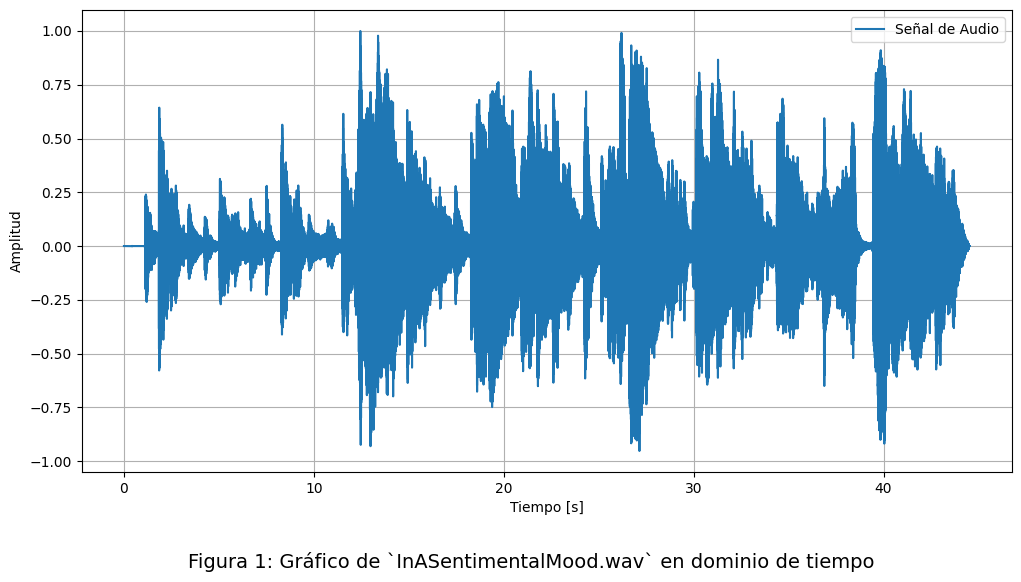

In [13]:
file1_figure = plt.figure(num=file1_figure_title, figsize=(12, 6))
file1_figure_caption = 'Figura 1: ' + file1_figure_title

file1_figure.text(.5, -0.05, file1_figure_caption, ha='center', fontsize=14)
plt.plot(file1_time, file1_data, label='Señal de Audio')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.show()

Para el segundo archivo, se repite exactamente el mismo procedimiento,
solo que en este caso cambia el nombre del archivo del cual se obtienen los
datos, en este caso siendo `Zombie.wav`.

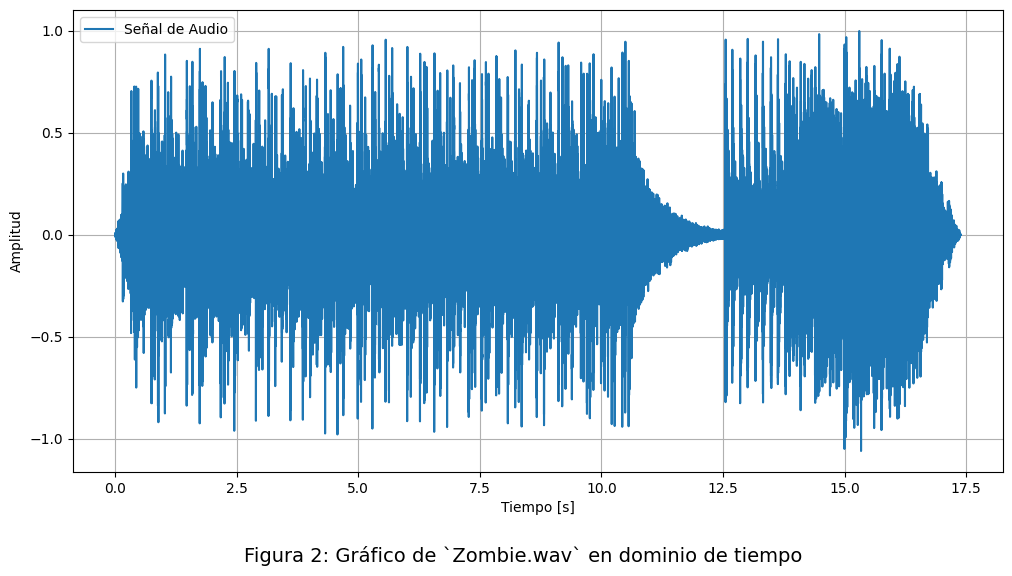

In [14]:
file2_sample_rate, file2_data = wavfile.read(file2_name)

file2_data = file2_data / np.max(file2_data)

file2_time = np.arange(len(file2_data)) / file2_sample_rate
file2_figure_title = 'Gráfico de `' + str(file2_name) + '` en dominio de tiempo'

file2_figure = plt.figure(num=file2_figure_title, figsize=(12, 6))
file2_figure_caption = 'Figura 2: ' + file2_figure_title

file2_figure.text(.5, -0.04, file2_figure_caption, ha='center', fontsize=14)

plt.plot(file2_time, file2_data, label='Señal de Audio')
# plt.title(file2_figure_title)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.show()

## Identificación de Notas Musicales

Para identificar las diferentes notas musicales del primer archivo (`InASentimentalMood.wav`),
analizamos visualmente el gráfico, reduciendo la escala de tiempo a un pequeño intervalo en zonas
específicas de la figura, como se muestra en la Figura 3 a continuación, en la cual se toma
el intervalo de tiempo `[1.13, 1.30]`.

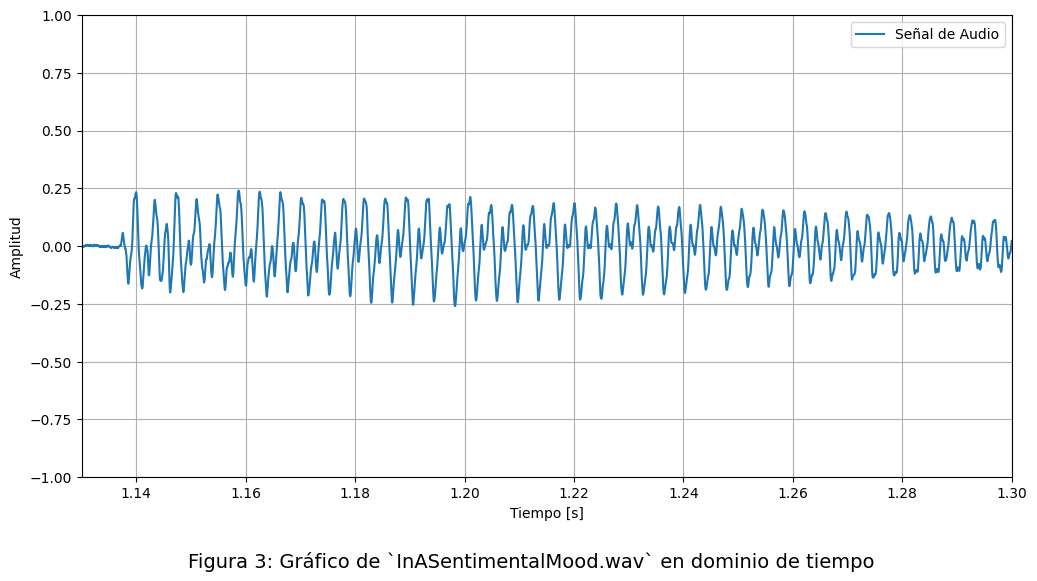

In [33]:
t = 1.13
dt = 0.17
amplitude = 1

figure_title = 'Gráfico de `' + str(file1_name) + '` en dominio de tiempo'

figure = plt.figure(num=figure_title, figsize=(12, 6))
figure_caption = 'Figura 3: ' + figure_title

figure.text(.5, -0.04, figure_caption, ha='center', fontsize=14)

data = file1_data / np.max(file1_data)

plt.figure(num=figure_title, figsize=(12, 6))
plt.plot(file1_time, data, label='Señal de Audio')
# plt.title(figure_title)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
# plt.axis([x_min, x_max, y_min, y_max])
plt.axis([t, t+dt, -amplitude, amplitude])
plt.legend()
plt.show()

Dicho intervalo de tiempo corresponde a la primera nota que puede escucharse en el archivo, producida por un piano, instrumento armónico. Si ampliamos el intervalo aún más, podremos distinguir la duración aproximada de un período (Figura 4).

![Frec_Piano](https://i.imgur.com/Bo0vS8s.png)

Dicho periodo es de aproximadamente 3.9 milisegundos, lo cual corresponde a una frecuencia fundamental de unos 256 Hz. En música, una frecuencia de 256 Hz se acerca más a una nota DO de la 4° octava.

A su vez, en la Figura 5, podemos observar visualmente una nota producida por un instrumento de viento, presumiblemente una trompeta.

![Frec_Trompeta](https://i.imgur.com/IHUxFbk.png)

La nota producida por este instrumento también tiene un periodo claramente distinguible, de unos 2.3 milisegundos, lo cual corresponde a unos 434 Hz y se acerca a una nota LA de la 4° octava (tomando como referencia el piano).

## Diferencias entre Instrumentos de Percusión y Armónicos

De manera análoga al análisis realizado para la Figura 1, se analiza la Figura 2, correspondiente
al segundo archivo, queriendo hallar diferencias notables entre los intrumentos de
percusión y los armónicos.

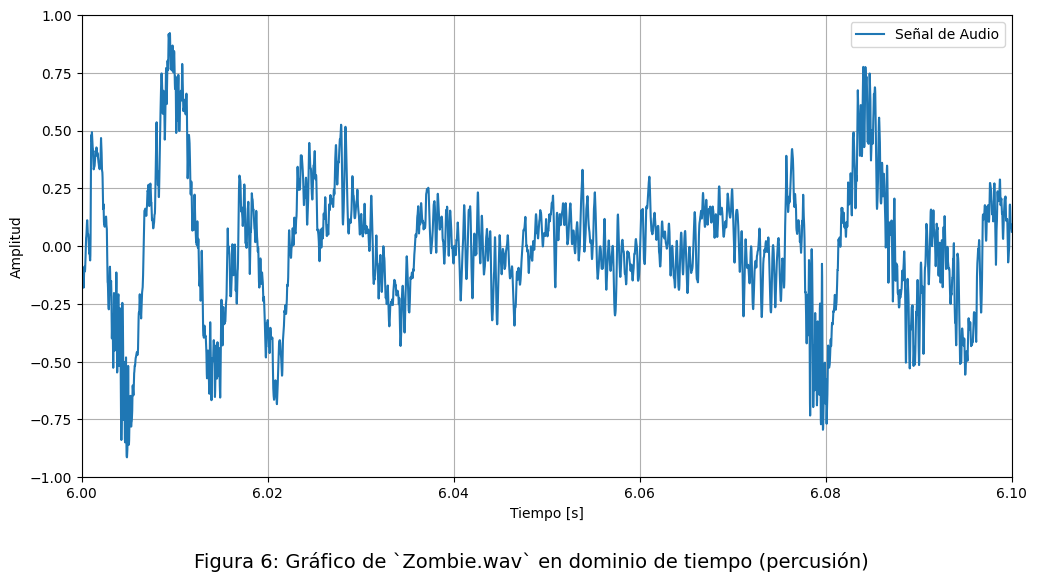

In [37]:
t = 6.0
dt = 0.1
amplitude = 1

figure_title = 'Gráfico de `' + str(file2_name) + '` en dominio de tiempo (percusión)'

figure = plt.figure(num=figure_title, figsize=(12, 6))
figure_caption = 'Figura 6: ' + figure_title

figure.text(.5, -0.04, figure_caption, ha='center', fontsize=14)

data = file2_data / np.max(file2_data)

plt.figure(num=figure_title, figsize=(12, 6))
plt.plot(file2_time, data, label='Señal de Audio')
# plt.title(figure_title)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.grid(True)
# plt.axis([x_min, x_max, y_min, y_max])
plt.axis([t, t+dt, -amplitude, amplitude])
plt.legend()
plt.show()

La diferencia fundamental es que los instrumentos en este archivo son enteramente de percusión, motivo por el cual la forma de onda resulta distinta a las vistas en las Figuras 4 y 5; no es posible distinguir "notas", y la frecuencia fundamental de los sonidos producidos no es fácilmente distinguible.